<a href="https://colab.research.google.com/github/fatwaratantjakusumajati/SMOTETomek-for-Balancing-Data-in-Diabetes-Classification-Using-XGBoost/blob/main/SMOTETomek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SKRIPSI

In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 120.5 MB/s eta 0:00:00


In [ ]:
#Library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier, plot_tree
from imblearn.combine import SMOTETomek
from collections import Counter
from graphviz import Digraph
import xgboost as xgb

Akuisisi Data

In [ ]:
from google.colab import files

# Pilih file kaggle.json yang diunduh
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vikasukani/diabetes-data-set

Dataset URL: https://www.kaggle.com/datasets/vikasukani/diabetes-data-set
License(s): other


In [ ]:
!unzip -q diabetes-data-set.zip

In [ ]:
df = pd.read_csv("/content/diabetes-dataset.csv")

In [ ]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
5,0,173,78,32,265,46.5,1.159,58,0
6,4,99,72,17,0,25.6,0.294,28,0
7,8,194,80,0,0,26.1,0.551,67,0
8,2,83,65,28,66,36.8,0.629,24,0
9,2,89,90,30,0,33.5,0.292,42,0


In [ ]:
df.shape

(2000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [ ]:
counts = df['Outcome'].value_counts()

print(counts)

Outcome
0    1316
1     684
Name: count, dtype: int64


In [ ]:
print(df)

      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               2      138             62             35        0  33.6   
1               0       84             82             31      125  38.2   
2               0      145              0              0        0  44.2   
3               0      135             68             42      250  42.3   
4               1      139             62             41      480  40.7   
...           ...      ...            ...            ...      ...   ...   
1995            2       75             64             24       55  29.7   
1996            8      179             72             42      130  32.7   
1997            6       85             78              0        0  31.2   
1998            0      129            110             46      130  67.1   
1999            2       81             72             15       76  30.1   

      DiabetesPedigreeFunction  Age  Outcome  
0                        0.127   47        1  
1    

Preprocessing

Cleaning Data

In [ ]:
columns_to_drop = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'SkinThickness']
df = df.drop([col for col in columns_to_drop if col in df.columns], axis=1)

df.head()

,Glucose,BloodPressure,BMI,Age,Outcome
0,138,62,33.6,47,1
1,84,82,38.2,23,0
2,145,0,44.2,31,1
3,135,68,42.3,24,1
4,139,62,40.7,21,0


In [ ]:
df.isnull().sum()

,0
Glucose,0
BloodPressure,0
BMI,0
Age,0
Outcome,0


In [ ]:
# Menghitung jumlah nilai 0 pada setiap kolom yang relevan
zero_counts = df[['Glucose', 'BloodPressure', 'BMI', 'Age']].apply(lambda x: (x == 0).sum())

print(zero_counts)

Glucose          13
BloodPressure    90
BMI              28
Age               0
dtype: int64


In [ ]:
# Ganti nilai 0 dengan mean kolom yang relevan
cols_to_replace = ['Glucose', 'BloodPressure', 'BMI', 'Age']

for col in cols_to_replace:
    mean_value = df[col].mean()
    df[col] = df[col].replace(0, mean_value)

# Cek DataFrame setelah penggantian
print(df[cols_to_replace])

      Glucose  BloodPressure   BMI  Age
0       138.0        62.0000  33.6   47
1        84.0        82.0000  38.2   23
2       145.0        69.1455  44.2   31
3       135.0        68.0000  42.3   24
4       139.0        62.0000  40.7   21
...       ...            ...   ...  ...
1995     75.0        64.0000  29.7   33
1996    179.0        72.0000  32.7   36
1997     85.0        78.0000  31.2   42
1998    129.0       110.0000  67.1   26
1999     81.0        72.0000  30.1   25

[2000 rows x 4 columns]


In [ ]:
# Menghitung jumlah nilai 0 pada setiap kolom yang relevan
zero_counts = df[['Glucose', 'BloodPressure', 'BMI', 'Age']].apply(lambda x: (x == 0).sum())

print(zero_counts)

Glucose          0
BloodPressure    0
BMI              0
Age              0
dtype: int64


In [ ]:
df

,Glucose,BloodPressure,BMI,Age,Outcome
0,138.0,62.0000,33.6,47,1
1,84.0,82.0000,38.2,23,0
2,145.0,69.1455,44.2,31,1
3,135.0,68.0000,42.3,24,1
4,139.0,62.0000,40.7,21,0
...,...,...,...,...,...
1995,75.0,64.0000,29.7,33,0
1996,179.0,72.0000,32.7,36,1
1997,85.0,78.0000,31.2,42,0
1998,129.0,110.0000,67.1,26,1


Normalisasi Data

In [ ]:
columns_to_normalize = ['Age', 'BloodPressure', 'BMI', 'Glucose', ]

scaler = MinMaxScaler()

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print (df)

       Glucose  BloodPressure       BMI       Age  Outcome
0     0.606452       0.387755  0.246795  0.433333        1
1     0.258065       0.591837  0.320513  0.033333        0
2     0.651613       0.460668  0.416667  0.166667        1
3     0.587097       0.448980  0.386218  0.050000        1
4     0.612903       0.387755  0.360577  0.000000        0
...        ...            ...       ...       ...      ...
1995  0.200000       0.408163  0.184295  0.200000        0
1996  0.870968       0.489796  0.232372  0.250000        1
1997  0.264516       0.551020  0.208333  0.350000        0
1998  0.548387       0.877551  0.783654  0.083333        1
1999  0.238710       0.489796  0.190705  0.066667        0

[2000 rows x 5 columns]


Memisahkan Feature dan Target

Feature target harus dihapus dari dataset karena target adalah variabel dependen yang ingin diprediksi oleh model.

In [ ]:
y = df.Outcome.values
X = df.drop(['Outcome'], axis = 1)

Balancing data

SMOTETomek

In [ ]:
# # Visualize the original dataset
# def plot_distribution(X, y, title):
#     # Konversi ke array numpy jika X adalah DataFrame
#     if hasattr(X, 'values'):
#         X = X.values

#     plt.figure(figsize=(10, 10))
#     # Mengurangi ukuran titik dari s=70 menjadi s=30 dan sedikit meningkatkan alpha untuk visibilitas yang lebih baik
#     plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
#                label='Majority Class',
#                alpha=1,
#                c='blue',
#                edgecolor='w',
#                s=30)
#     plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
#                label='Minority Class',
#                alpha=1,
#                c='red',
#                edgecolor='w',
#                s=30)
#     plt.title(title)
#     plt.legend()
#     plt.show()

# plot_distribution(X, y, 'Original Imbalanced Data')
def plot_distribution(X, y, title, figsize=(10, 8)):
    """
    Memvisualisasikan distribusi kelas dalam dataset.

    Parameters:
    -----------
    X : array-like of shape (n_samples, 2)
        Data fitur yang akan divisualisasikan (harus 2 dimensi)
    y : array-like of shape (n_samples,)
        Label kelas (0 untuk mayoritas, 1 untuk minoritas)
    title : str
        Judul plot
    figsize : tuple, optional (default=(10, 8))
        Ukuran figure dalam inches
    """
    # Konversi ke array numpy jika X adalah DataFrame
    if hasattr(X, 'values'):
        X = X.values

    # Hitung jumlah sampel per kelas
    n_majority = sum(y == 0)
    n_minority = sum(y == 1)
    ratio = n_minority / len(y) * 100

    # Buat plot dengan style default
    plt.figure(figsize=figsize, facecolor='white')

    # Plot data
    majority = plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
                         label=f'Majority Class (n={n_majority})',
                         alpha=0.6,
                         c='#3498db',  # Warna biru yang lebih menarik
                         edgecolor='white',
                         s=80,
                         marker='o')

    minority = plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
                         label=f'Minority Class (n={n_minority})',
                         alpha=0.6,
                         c='#e74c3c',  # Warna merah yang lebih menarik
                         edgecolor='white',
                         s=80,
                         marker='o')

    # Tambahkan judul dan informasi
    plt.title(f'{title}\nClass Distribution Ratio: {ratio:.1f}%',
              fontsize=12, pad=20)

    # Tambahkan label axis
    plt.xlabel('Feature 1', fontsize=10)
    plt.ylabel('Feature 2', fontsize=10)

    # Perbaikan legend
    plt.legend(loc='upper right',
              bbox_to_anchor=(1.15, 1),
              frameon=True,
              fancybox=True,
              shadow=True,
              fontsize=10)

    # Tambahkan grid dengan style yang lebih halus
    plt.grid(True, linestyle='--', alpha=0.3)

    # Atur warna background axes menjadi putih
    plt.gca().set_facecolor('white')

    # Atur layout agar tidak terpotong
    plt.tight_layout()

    # Tampilkan plot
    plt.show()

# Contoh penggunaan:
# plot_distribution(X, y, 'Imbalanced Dataset Distribution')

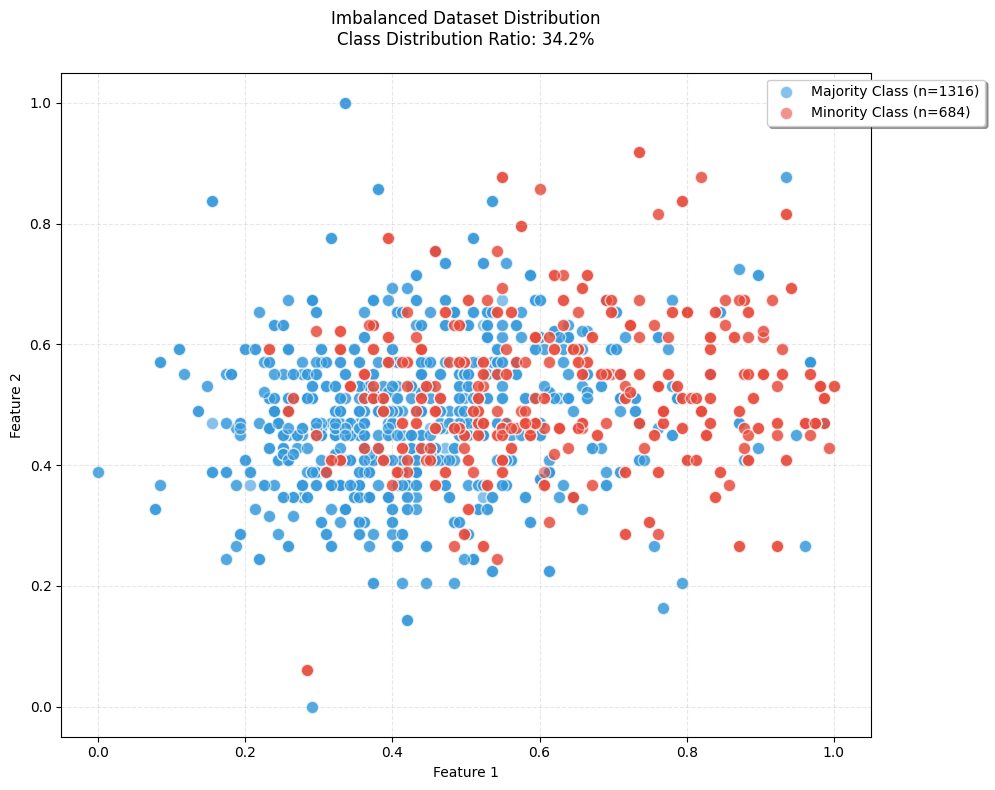

In [ ]:
# Contoh penggunaan:
plot_distribution(X, y, 'Imbalanced Dataset Distribution')

In [ ]:
#Pass the SMOTE instance to SMOTETomek
st = SMOTETomek(random_state=42)

print('Original dataset shape %s' % Counter(y))

Original dataset shape Counter({np.int64(0): 1316, np.int64(1): 684})


In [ ]:
x_train_st, y_train_st = st.fit_resample(X, y)
print('Resampled ytrain dataset shape %s' % Counter(y_train_st))
print (x_train_st)
print (y_train_st)

Resampled ytrain dataset shape Counter({np.int64(1): 1316, np.int64(0): 1316})
       Glucose  BloodPressure       BMI       Age
0     0.606452       0.387755  0.246795  0.433333
1     0.258065       0.591837  0.320513  0.033333
2     0.651613       0.460668  0.416667  0.166667
3     0.587097       0.448980  0.386218  0.050000
4     0.612903       0.387755  0.360577  0.000000
...        ...            ...       ...       ...
2627  0.573921       0.454948  0.393582  0.067019
2628  0.497952       0.571429  0.365385  0.266667
2629  0.586779       0.449124  0.386396  0.050411
2630  0.490323       0.460668  0.189103  0.283333
2631  0.262643       0.491405  0.186317  0.416667

[2632 rows x 4 columns]
[1 0 1 ... 1 1 1]


In [ ]:
# Menghitung distribusi kelas setelah SMOTE-Tomek
print("\nDistribusi kelas setelah SMOTE-Tomek:")
print(pd.Series(y_train_st).value_counts())


Distribusi kelas setelah SMOTE-Tomek:
1    1316
0    1316
Name: count, dtype: int64


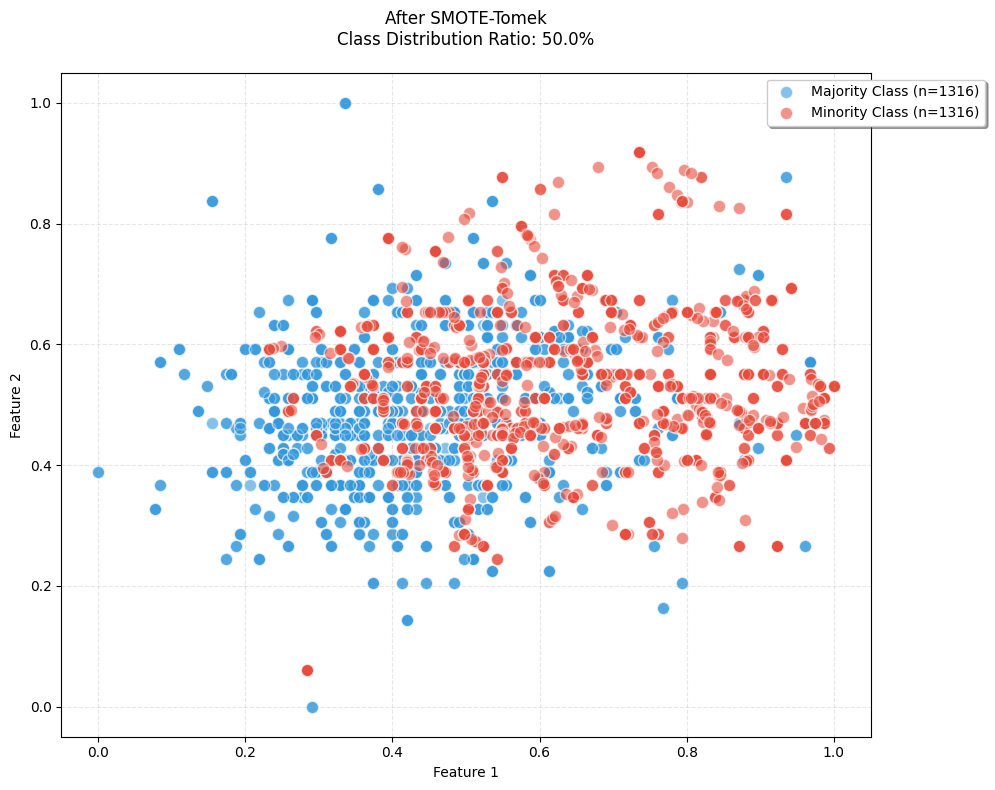

In [ ]:
# Visualize the resampled dataset
plot_distribution(x_train_st, y_train_st, 'After SMOTE-Tomek')

Training Testing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_train_st,y_train_st,test_size = 0.2,random_state=0)

In [ ]:
# Menampilkan jumlah data training dan data testing
print("Jumlah data training:", x_train.shape[0])
print("Jumlah data testing:", x_test.shape[0])

Jumlah data training: 2105
Jumlah data testing: 527


Creating Model

XGboost - SMOTETomek

In [ ]:
accuracies = {}

In [ ]:
# Inisialisasi model XGBoost dengan parameter n_estimators, learning_rate, dan max_depth
model = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=3)

In [ ]:
# Melakukan k-fold cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy')

In [ ]:
# Menampilkan hasil cross-validation
print("Hasil Cross-Validation (Accuracy):")
print(scores)
print("Rata-rata Accuracy:", np.mean(scores))

Hasil Cross-Validation (Accuracy):
[0.84188034 0.8019943  0.83166904]
Rata-rata Accuracy: 0.8251812293657276


In [ ]:
scoreList = []
for i in range(1, 500):
    model = XGBClassifier(n_estimators=i)
    model.fit(x_train, y_train)
    scores = cross_val_score(model, x_train, y_train, cv=3)  # Cross-validation with 3 folds
    score = np.mean(scores)
    scoreList.append(score)

optimal_n_estimators = scoreList.index(max(scoreList)) + 1
print("Jumlah pohon terbaik adalah", optimal_n_estimators)
print("Akurasi terbaik adalah {:.2f}%".format(max(scoreList)*100))

Jumlah pohon terbaik adalah 109
Akurasi terbaik adalah 95.25%


In [ ]:
def save_tree_visualization(model, num_tree=0, filename="tree_visualization"):
    # Gunakan fungsi plot_tree dari XGBoost
    plt.figure(figsize=(20,10))
    xgb.plot_tree(model, num_trees=num_tree, rankdir='LR')

    # Simpan plot ke file
    plt.savefig(f"{filename}.png", bbox_inches='tight')
    plt.close()
    print(f"Pohon keputusan disimpan sebagai {filename}.png")

In [ ]:
# Panggil fungsi untuk menyimpan pohon keputusan pertama
save_tree_visualization(model, num_tree=0, filename="tree_visualization_SMOTETomek")


Pohon keputusan disimpan sebagai tree_visualization_SMOTETomek.png


<Figure size 2000x1000 with 0 Axes>

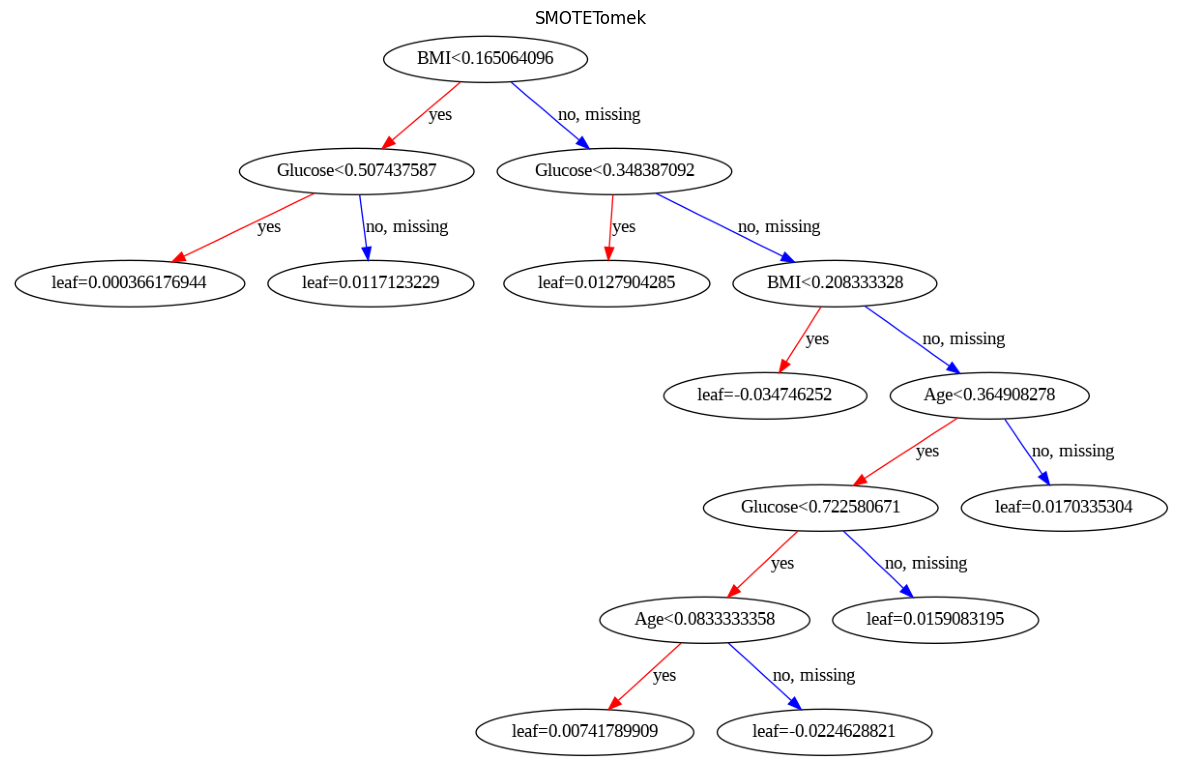

<Figure size 1500x4000 with 0 Axes>

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 15,40
plot_tree(model, num_trees=-1, rankdir='TB')
plt.title('SMOTETomek')
plt.show()
plt.savefig('tree.png')

In [ ]:
# Re-train the model with the optimal number of estimators
optimal_model = XGBClassifier(n_estimators=optimal_n_estimators, random_state=42)
optimal_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=109, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Prediksi dengan model yang dilatih
y_pred = optimal_model.predict(x_test)

Mean Squared Error: 0.024667931688804556
Accuracy on Test Data: 95.25%


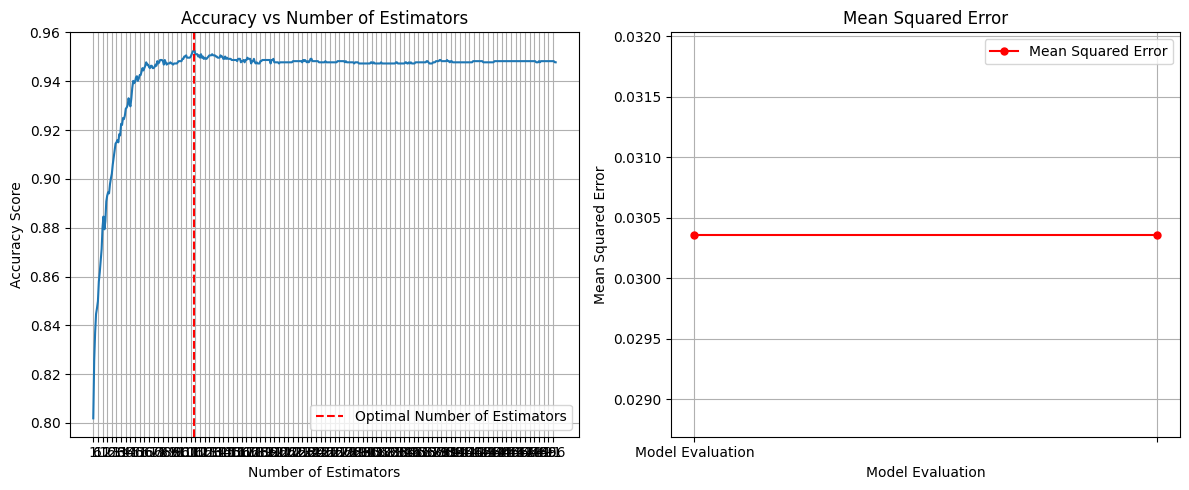

In [ ]:
# Plotting akurasi dan error
plt.figure(figsize=(12, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(range(1, 500), scoreList)
plt.axvline(x=optimal_n_estimators, color='r', linestyle='--', label='Optimal Number of Estimators')
plt.xticks(np.arange(1, 500, 5))
plt.grid(True)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy Score")
plt.title("Accuracy vs Number of Estimators")
plt.legend()

# Menghitung dan menyimpan MSE
mseList = []
for i in range(1, 500):
    model.set_params(n_estimators=i)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    mseList.append(mse)

# Menampilkan MSE
optimal_mse = mseList[optimal_n_estimators - 1]
print("Mean Squared Error:", optimal_mse)

# Hitung dan tampilkan akurasi model pada data uji
print("Accuracy on Test Data: {:.2f}%".format(max(scoreList) * 100))

# Plot MSE
plt.subplot(1, 2, 2)
plt.plot([1, 2], [mse, mse], marker='o', markersize=5, color="red", label='Mean Squared Error')
plt.xticks([1, 2], ['Model Evaluation', ''])
plt.title('Mean Squared Error')
plt.xlabel('Model Evaluation')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

acc = max(scoreList) * 100
accuracies['XGBoost'] = acc

# Save the model
filename = 'XGBoost_Model.pkl'
pickle.dump(model, open(filename, 'wb'))

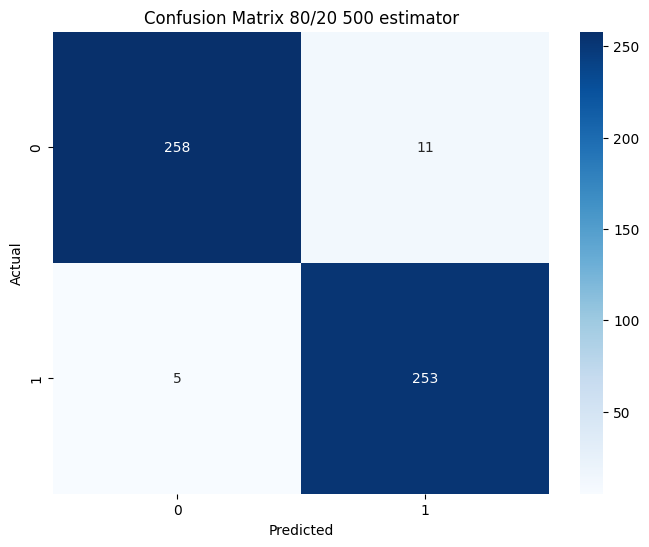

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       269
           1       0.96      0.98      0.97       258

    accuracy                           0.97       527
   macro avg       0.97      0.97      0.97       527
weighted avg       0.97      0.97      0.97       527



In [ ]:
# Hitung matriks kebingungan
cm = confusion_matrix(y_test, y_pred)

# Plot matriks kebingungan menggunakan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix 80/20 500 estimator')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cetak laporan klasifikasi
report = classification_report(y_test.T, y_pred)
print(report)

In [ ]:
# filename = 'XGBoost_Model.pkl'

# try:
#     loaded_model = pickle.load(open(filename, 'rb'))
# except FileNotFoundError:
#     print("File", filename, "not found.")
#     exit()

# new_data = pd.DataFrame({'Glucose': [30], 'BloodPressure': [82], 'BMI': [47.8], 'Age': [45]})

# # Prediksi kelas dari data baru
# predicted_class = loaded_model.predict(new_data)

# if predicted_class == 0:
#     print(predicted_class, ": Tidak")
# elif predicted_class == 1:
#     print(predicted_class, ": Iya")